In [23]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

# [TIMING] Boot up complete in 88.21 seconds.
# [TIMING] Sweep finished in 246.90 seconds.

wl = np.load('wavelength.npy')
angles_raw = np.load('calibration_table.npy')[:, 0]
data_raw = np.load('calibration_data.npy') 

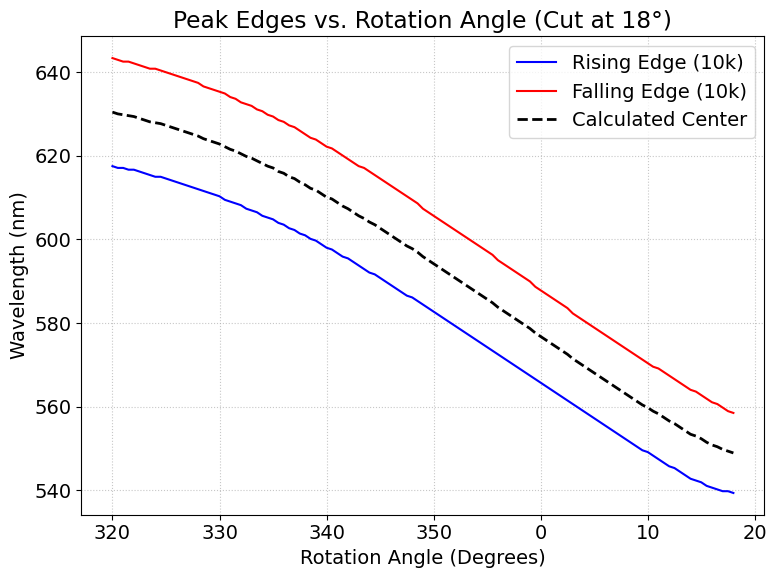

In [27]:
valid_angle_mask = (angles_raw >= 320) | (angles_raw <= 18)
angles = angles_raw[valid_angle_mask]
data = data_raw[valid_angle_mask]

threshold = 10000

rising_edges = []
falling_edges = []
center_wls = []

# EXPANDED SEARCH WINDOW: 520nm to 660nm
window_mask = (wl >= 520) & (wl <= 660)
wl_window = wl[window_mask]

# --- 3. Extract Edges ---
for i in range(len(angles)):
    spectrum = data[i, window_mask]
    
    # Find all indices where the signal is above the threshold
    above_thresh = np.where(spectrum > threshold)[0]
    
    if len(above_thresh) > 0:
        # The first time it crosses the threshold
        rise_idx = above_thresh[0]
        # The last time it is above the threshold
        fall_idx = above_thresh[-1]
        
        rise_wl = wl_window[rise_idx]
        fall_wl = wl_window[fall_idx]
        
        # Calculate the mathematical center between the two edges
        center_wl = (rise_wl + fall_wl) / 2.0
        
        rising_edges.append(rise_wl)
        falling_edges.append(fall_wl)
        center_wls.append(center_wl)
    else:
        # If the peak never hits 10k at this specific angle
        rising_edges.append(np.nan)
        falling_edges.append(np.nan)
        center_wls.append(np.nan)

# --- 4. Unwrap Angles for a Smooth Plot ---
# If an angle is small (e.g., 0 to 18), add 360 to it so the line continues seamlessly
plot_angles = np.array([a + 360 if a < 180 else a for a in angles])

# --- 5. Plotting ---
plt.figure(figsize=(8, 6))

plt.plot(plot_angles, rising_edges, 'b-', label='Rising Edge (10k)')
plt.plot(plot_angles, falling_edges, 'r-', label='Falling Edge (10k)')
plt.plot(plot_angles, center_wls, 'k--', label='Calculated Center', linewidth=2)

plt.xlabel('Rotation Angle (Degrees)')
plt.ylabel('Wavelength (nm)')
plt.title('Peak Edges vs. Rotation Angle (Cut at 18°)')

# Create custom tick labels so "370" visually shows up as "10" on the graph
ticks = np.arange(320, 381, 10)
tick_labels = [str(t % 360) for t in ticks]
plt.xticks(ticks, tick_labels)

plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

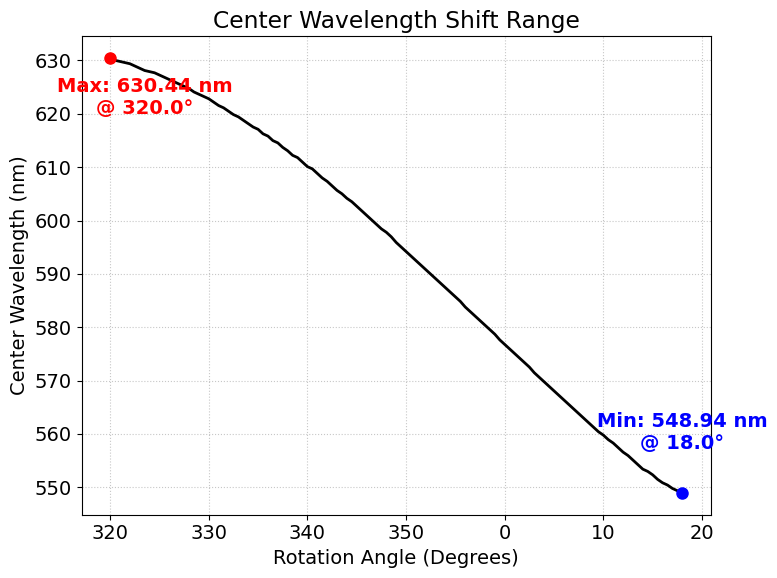

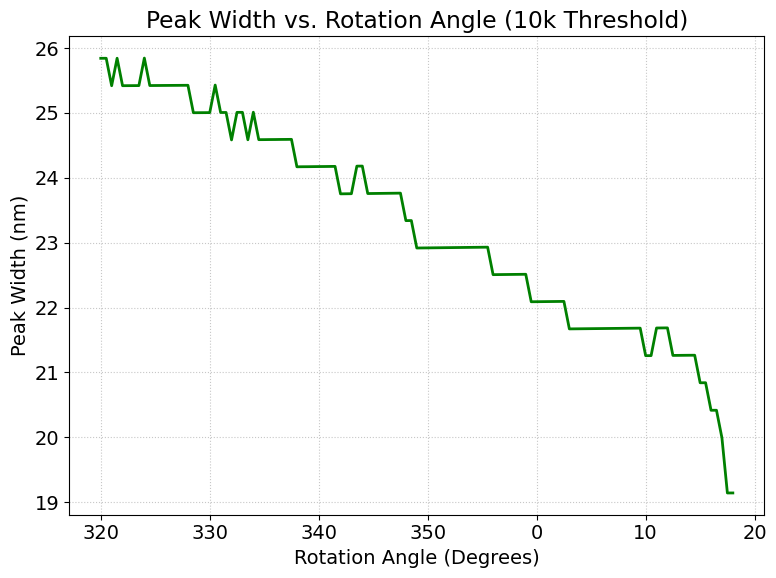

In [37]:
# --- 6. Additional Calculations ---
# Convert lists to numpy arrays for easier math
center_wls_arr = np.array(center_wls)
rising_edges_arr = np.array(rising_edges)
falling_edges_arr = np.array(falling_edges)

# Calculate the width (Full Width at 10k Threshold)
peak_widths = falling_edges_arr - rising_edges_arr

# Find the max and min center wavelengths and their corresponding angles
valid_mask = ~np.isnan(center_wls_arr) # Ignore nan values
if np.any(valid_mask):
    max_idx = np.nanargmax(center_wls_arr)
    min_idx = np.nanargmin(center_wls_arr)
    
    max_wl = center_wls_arr[max_idx]
    min_wl = center_wls_arr[min_idx]
    
    max_angle_plot = plot_angles[max_idx]
    min_angle_plot = plot_angles[min_idx]
    
    # Get the actual physical angle (0-360) for the text labels
    max_angle_actual = angles[max_idx]
    min_angle_actual = angles[min_idx]

# --- 7. Plotting the Center Wavelength Range ---
plt.figure(figsize=(8, 6))

plt.plot(plot_angles, center_wls_arr, 'k-', label='Calculated Center', linewidth=2)

# Mark the max and min points
if np.any(valid_mask):
    plt.plot(max_angle_plot, max_wl, 'ro', markersize=8)
    plt.plot(min_angle_plot, min_wl, 'bo', markersize=8)
    
    # Add text annotations
    plt.annotate(f'Max: {max_wl:.2f} nm\n@ {max_angle_actual:.1f}°', 
                 xy=(max_angle_plot, max_wl), xytext=(25, -40), 
                 textcoords='offset points', ha='center', color='red', weight='bold')
    
    plt.annotate(f'Min: {min_wl:.2f} nm\n@ {min_angle_actual:.1f}°', 
                 xy=(min_angle_plot, min_wl), xytext=(0, 32), 
                 textcoords='offset points', ha='center', color='blue', weight='bold')

plt.xlabel('Rotation Angle (Degrees)')
plt.ylabel('Center Wavelength (nm)')
plt.title('Center Wavelength Shift Range')

plt.xticks(ticks, tick_labels)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 8. Plotting the Peak Width ---
plt.figure(figsize=(8, 6))

plt.plot(plot_angles, peak_widths, 'g-', label='Peak Width (Falling - Rising)', linewidth=2)

plt.xlabel('Rotation Angle (Degrees)')
plt.ylabel('Peak Width (nm)')
plt.title('Peak Width vs. Rotation Angle (10k Threshold)')

plt.xticks(ticks, tick_labels)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

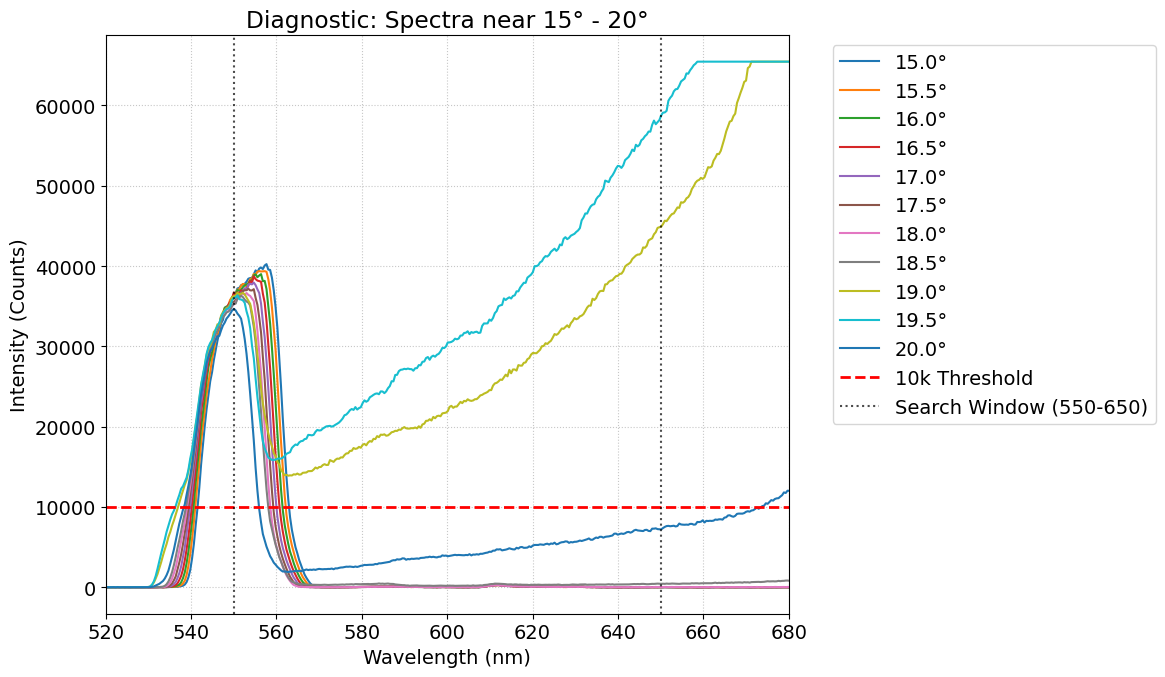

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 14

# --- 1. Load Data ---
wl = np.load('wavelength.npy')
angles = np.load('calibration_table.npy')[:, 0]
data = np.load('calibration_data.npy')

# --- 2. Filter for angles near the end (e.g., 15° to 20°) ---
# Because of how we did the sweep, the angles 15-20 are at the very end of the array
target_indices = np.where((angles >= 15) & (angles <= 20))[0]

# --- 3. Plotting ---
plt.figure(figsize=(12, 7))

# Plot each spectrum in that range
for idx in target_indices:
    angle = angles[idx]
    spectrum = data[idx, :]
    plt.plot(wl, spectrum, label=f'{angle:.1f}°')

# Add the 10k threshold line for reference
plt.axhline(10000, color='red', linestyle='--', linewidth=2, label='10k Threshold')

# Highlight the 550-650nm search window boundaries we used earlier
plt.axvline(550, color='black', linestyle=':', alpha=0.7, label='Search Window (550-650)')
plt.axvline(650, color='black', linestyle=':', alpha=0.7)

# Zoom in on the action to see if it shifted out of bounds
plt.xlim(520, 680) 

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (Counts)')
plt.title('Diagnostic: Spectra near 15° - 20°')

# Put the legend outside the plot so it doesn't cover the peaks
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()